In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

NAVY = "#1E2761"
ACCENT = "#FF6B4A"
GREY = "#8A93A8"

df = pd.read_excel(r"C:\Users\SAIM\Downloads\Dataset for Data Analytics (1).xlsx")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [2]:
print("Shape:", df.shape)
print()
print(df.dtypes)

Shape: (1200, 14)

OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object


In [3]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
OrderID,1200,1200,ORD200000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,1200,NaN,NaN,NaN,2024-03-22 16:58:48,2023-01-01 00:00:00,2023-08-03 18:00:00,2024-03-23 00:00:00,2024-11-08 12:00:00,2025-06-30 00:00:00,NaN
CustomerID,1200,1189,C38840,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,1200,7,Printer,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1200.0,NaN,NaN,NaN,2.945833,1.0,2.0,3.0,4.0,5.0,1.407557
UnitPrice,1200.0,NaN,NaN,NaN,356.41275,11.39,186.0625,364.21,521.57,699.93,197.177146
ShippingAddress,1200,655,533 Main St,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaymentMethod,1200,5,Online,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OrderStatus,1200,5,Cancelled,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TrackingNumber,1200,1200,TRK37947903,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
total_revenue = df['TotalPrice'].sum()
total_orders = len(df)
aov = df['TotalPrice'].mean()
date_min, date_max = df['Date'].min(), df['Date'].max()

print(f"Total Revenue (booked):  ${total_revenue:,.0f}")
print(f"Total Orders:            {total_orders:,}")
print(f"Average Order Value:     ${aov:,.2f}")
print(f"Date Range:              {date_min.date()}  to  {date_max.date()}")
print(f"Product categories:      {df['Product'].nunique()}  -> {sorted(df['Product'].unique())}")
print(f"Payment methods:         {df['PaymentMethod'].nunique()}  -> {sorted(df['PaymentMethod'].unique())}")
print(f"Acquisition channels:    {df['ReferralSource'].nunique()}  -> {sorted(df['ReferralSource'].unique())}")

Total Revenue (booked):  $1,264,762
Total Orders:            1,200
Average Order Value:     $1,053.97
Date Range:              2023-01-01  to  2025-06-30
Product categories:      7  -> ['Chair', 'Desk', 'Laptop', 'Monitor', 'Phone', 'Printer', 'Tablet']
Payment methods:         5  -> ['Cash', 'Credit Card', 'Debit Card', 'Gift Card', 'Online']
Acquisition channels:    5  -> ['Email', 'Facebook', 'Google', 'Instagram', 'Referral']


In [6]:
status_summary = df.groupby('OrderStatus')['TotalPrice'].agg(['count', 'sum']).sort_values('sum', ascending=False)
status_summary.columns = ['Order Count', 'Revenue']
status_summary

,Order Count,Revenue
OrderStatus,,
Cancelled,250,276396.21
Pending,237,256328.15
Shipped,235,246159.58
Returned,247,243277.70
Delivered,231,242600.32


In [7]:
at_risk_statuses = ['Cancelled', 'Returned']
realized_statuses = ['Delivered', 'Shipped', 'Pending']

at_risk_rev = df.loc[df['OrderStatus'].isin(at_risk_statuses), 'TotalPrice'].sum()
realized_rev = df.loc[df['OrderStatus'].isin(realized_statuses), 'TotalPrice'].sum()
at_risk_orders = df['OrderStatus'].isin(at_risk_statuses).sum()
realized_orders = df['OrderStatus'].isin(realized_statuses).sum()

pct_rev_at_risk = at_risk_rev / total_revenue * 100
pct_orders_at_risk = at_risk_orders / total_orders * 100

print(f"Realized revenue:  ${realized_rev:,.0f}  ({realized_orders} orders)")
print(f"At-risk revenue:   ${at_risk_rev:,.0f}  ({at_risk_orders} orders)")
print(f"% of revenue at risk:  {pct_rev_at_risk:.1f}%")
print(f"% of orders at risk:   {pct_orders_at_risk:.1f}%")

Realized revenue:  $745,088  (703 orders)
At-risk revenue:   $519,674  (497 orders)
% of revenue at risk:  41.1%
% of orders at risk:   41.4%


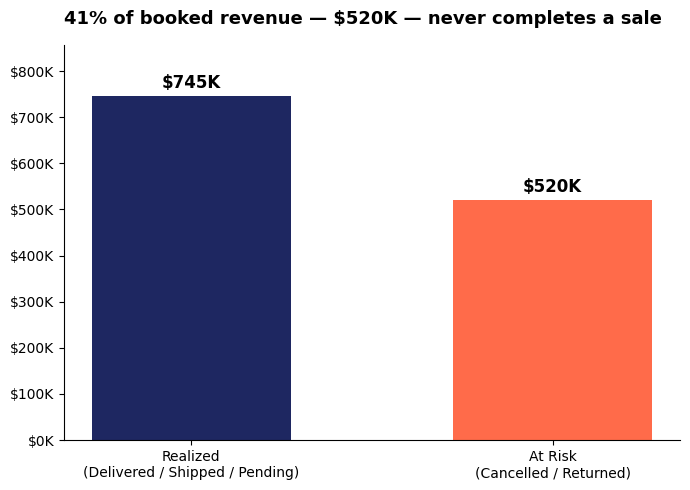

In [8]:
# Chart: Realized vs At-Risk revenue — bar chart, zero-baseline, direct labels, single spotlight color
fig, ax = plt.subplots(figsize=(7, 5))
labels = ['Realized\n(Delivered / Shipped / Pending)', 'At Risk\n(Cancelled / Returned)']
values = [realized_rev, at_risk_rev]
colors = [NAVY, ACCENT]

bars = ax.bar(labels, values, color=colors, width=0.55)
ax.set_ylim(0, max(values) * 1.15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
ax.set_title("41% of booked revenue — $520K — never completes a sale", fontsize=13, fontweight='bold', loc='left', pad=15)
ax.grid(False)

for bar, val in zip(bars, values):
    ax.annotate(f"${val/1000:,.0f}K", xy=(bar.get_x() + bar.get_width()/2, val),
                xytext=(0, 6), textcoords="offset points", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("chart_revenue_at_risk.png", dpi=150)
plt.show()

In [9]:
df['Quarter'] = df['Date'].dt.to_period('Q').astype(str)
quarterly_revenue = df.groupby('Quarter')['TotalPrice'].sum()
quarterly_revenue

Quarter
2023Q1    145412.78
2023Q2    141088.74
2023Q3    126699.47
2023Q4    139442.25
2024Q1    111468.55
2024Q2    145590.79
2024Q3    114750.03
2024Q4    108426.50
2025Q1    103617.61
2025Q2    128265.24
Name: TotalPrice, dtype: float64

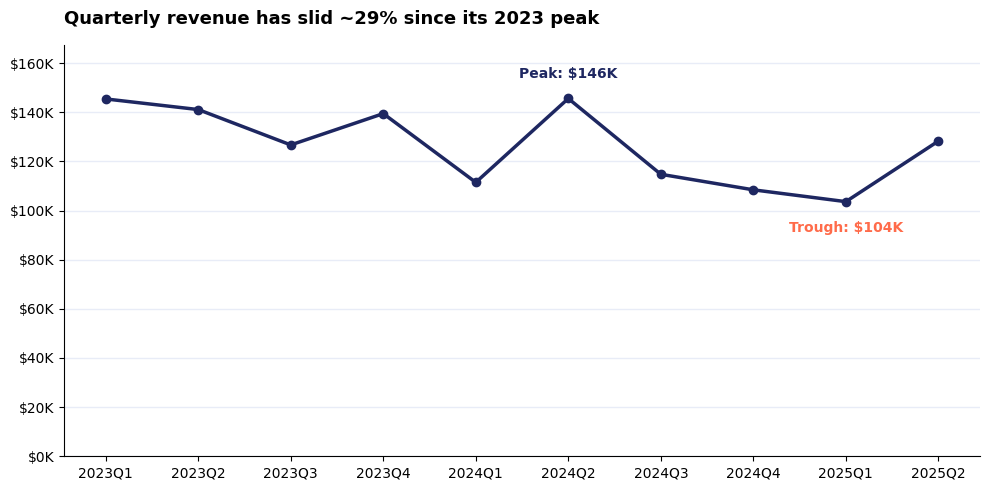

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(quarterly_revenue.index, quarterly_revenue.values, marker='o', color=NAVY, linewidth=2.5, markersize=6)
ax.set_ylim(0, quarterly_revenue.max() * 1.15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
ax.set_title("Quarterly revenue has slid ~29% since its 2023 peak", fontsize=13, fontweight='bold', loc='left', pad=15)
ax.grid(axis='y', color='#E8ECF7', linewidth=1)

peak_q = quarterly_revenue.idxmax()
trough_q = quarterly_revenue.idxmin()
ax.annotate(f"Peak: ${quarterly_revenue[peak_q]/1000:,.0f}K", xy=(peak_q, quarterly_revenue[peak_q]),
            xytext=(0, 15), textcoords="offset points", ha='center', fontweight='bold', color=NAVY)
ax.annotate(f"Trough: ${quarterly_revenue[trough_q]/1000:,.0f}K", xy=(trough_q, quarterly_revenue[trough_q]),
            xytext=(0, -22), textcoords="offset points", ha='center', fontweight='bold', color=ACCENT)

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("chart_quarterly_trend.png", dpi=150)
plt.show()

In [11]:
pct_change = (quarterly_revenue[peak_q] - quarterly_revenue[trough_q]) / quarterly_revenue[peak_q] * 100
print(f"Peak quarter: {peak_q}  (${quarterly_revenue[peak_q]:,.0f})")
print(f"Trough quarter: {trough_q}  (${quarterly_revenue[trough_q]:,.0f})")
print(f"Decline from peak to trough: {pct_change:.1f}%")

Peak quarter: 2024Q2  ($145,591)
Trough quarter: 2025Q1  ($103,618)
Decline from peak to trough: 28.8%


In [12]:
cancel_return_by_payment = df.groupby('PaymentMethod').apply(
    lambda g: (g['OrderStatus'].isin(at_risk_statuses)).mean() * 100
).sort_values()
cancel_return_by_payment

C:\Users\SAIM\AppData\Local\Temp\ipykernel_14580\81243817.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cancel_return_by_payment = df.groupby('PaymentMethod').apply(


PaymentMethod
Online         35.271318
Debit Card     40.948276
Cash           43.089431
Credit Card    44.017094
Gift Card      44.347826
dtype: float64

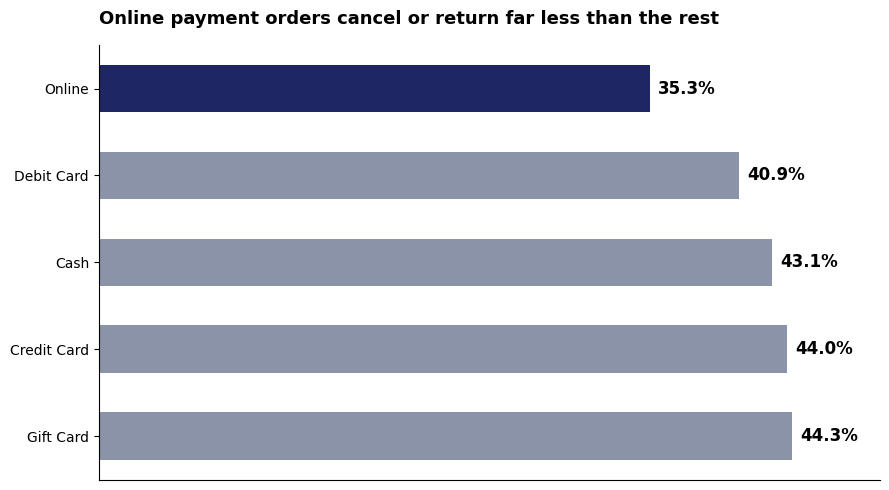

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
labels = cancel_return_by_payment.index
values = cancel_return_by_payment.values
colors = [NAVY] + [GREY] * (len(labels) - 1)

bars = ax.barh(labels, values, color=colors, height=0.55)
ax.invert_yaxis()
ax.set_xlim(0, 50)
ax.set_title("Online payment orders cancel or return far less than the rest", fontsize=13, fontweight='bold', loc='left', pad=15)
ax.grid(False)
ax.set_xticks([])

for bar, val in zip(bars, values):
    ax.annotate(f"{val:.1f}%", xy=(val, bar.get_y() + bar.get_height()/2),
                xytext=(6, 0), textcoords="offset points", va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("chart_payment_reliability.png", dpi=150)
plt.show()

In [14]:
cancel_return_by_referral = df.groupby('ReferralSource').apply(
    lambda g: (g['OrderStatus'].isin(at_risk_statuses)).mean() * 100
).sort_values()
cancel_return_by_referral

C:\Users\SAIM\AppData\Local\Temp\ipykernel_14580\1073249661.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cancel_return_by_referral = df.groupby('ReferralSource').apply(


ReferralSource
Instagram    37.065637
Google       41.908714
Referral     42.342342
Facebook     42.982456
Email        43.200000
dtype: float64

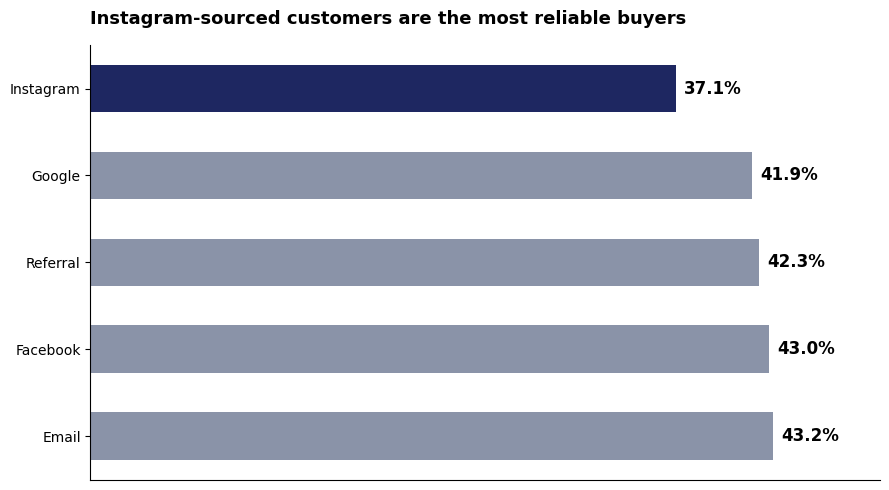

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
labels = cancel_return_by_referral.index
values = cancel_return_by_referral.values
colors = [NAVY] + [GREY] * (len(labels) - 1)

bars = ax.barh(labels, values, color=colors, height=0.55)
ax.invert_yaxis()
ax.set_xlim(0, 50)
ax.set_title("Instagram-sourced customers are the most reliable buyers", fontsize=13, fontweight='bold', loc='left', pad=15)
ax.grid(False)
ax.set_xticks([])

for bar, val in zip(bars, values):
    ax.annotate(f"{val:.1f}%", xy=(val, bar.get_y() + bar.get_height()/2),
                xytext=(6, 0), textcoords="offset points", va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("chart_referral_reliability.png", dpi=150)
plt.show()

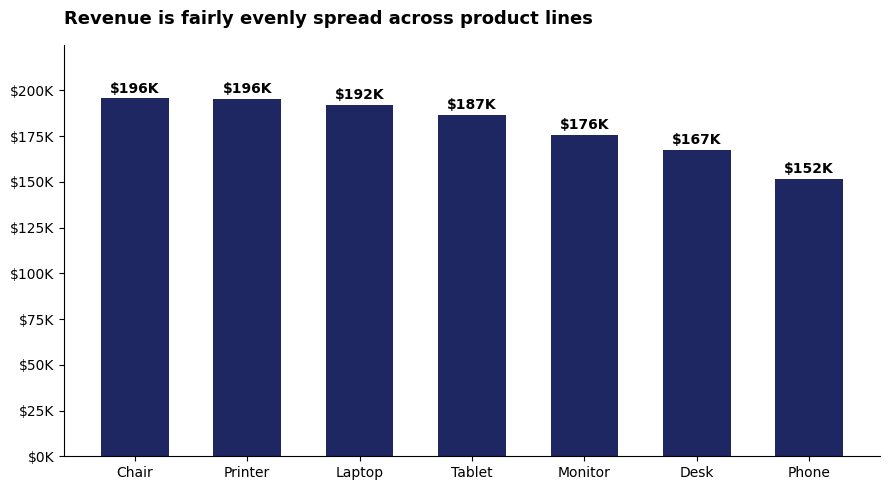

In [16]:
revenue_by_product = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(revenue_by_product.index, revenue_by_product.values, color=NAVY, width=0.6)
ax.set_ylim(0, revenue_by_product.max() * 1.15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
ax.set_title("Revenue is fairly evenly spread across product lines", fontsize=13, fontweight='bold', loc='left', pad=15)
ax.grid(False)

for bar, val in zip(bars, revenue_by_product.values):
    ax.annotate(f"${val/1000:,.0f}K", xy=(bar.get_x() + bar.get_width()/2, val),
                xytext=(0, 4), textcoords="offset points", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("chart_revenue_by_product.png", dpi=150)
plt.show()

In [17]:
import sqlite3

conn = sqlite3.connect(":memory:")
df.drop(columns=['Quarter']).to_sql("orders", conn, index=False, if_exists="replace")

def run(query):
    return pd.read_sql_query(query, conn)

In [18]:
# KPI overview
run("""
SELECT
    COUNT(*)              AS total_orders,
    ROUND(SUM(TotalPrice), 2)  AS total_revenue,
    ROUND(AVG(TotalPrice), 2)  AS avg_order_value,
    MIN(Date)             AS first_order,
    MAX(Date)             AS last_order
FROM orders;
""")

,total_orders,total_revenue,avg_order_value,first_order,last_order
0,1200,1264761.96,1053.97,2023-01-01 00:00:00,2025-06-30 00:00:00


In [19]:
# Revenue at risk vs realized
run("""
SELECT
    CASE WHEN OrderStatus IN ('Cancelled', 'Returned') THEN 'At Risk' ELSE 'Realized' END AS bucket,
    COUNT(*)                  AS order_count,
    ROUND(SUM(TotalPrice), 2) AS revenue
FROM orders
GROUP BY bucket;
""")

,bucket,order_count,revenue
0,At Risk,497,519673.91
1,Realized,703,745088.05


In [20]:
# Cancel/Return rate by payment method
run("""
SELECT
    PaymentMethod,
    ROUND(100.0 * SUM(CASE WHEN OrderStatus IN ('Cancelled','Returned') THEN 1 ELSE 0 END) / COUNT(*), 1)
        AS cancel_return_rate_pct
FROM orders
GROUP BY PaymentMethod
ORDER BY cancel_return_rate_pct;
""")

,PaymentMethod,cancel_return_rate_pct
0,Online,35.3
1,Debit Card,40.9
2,Cash,43.1
3,Credit Card,44.0
4,Gift Card,44.3


In [21]:
# Cancel/Return rate by referral source
run("""
SELECT
    ReferralSource,
    ROUND(100.0 * SUM(CASE WHEN OrderStatus IN ('Cancelled','Returned') THEN 1 ELSE 0 END) / COUNT(*), 1)
        AS cancel_return_rate_pct
FROM orders
GROUP BY ReferralSource
ORDER BY cancel_return_rate_pct;
""")

,ReferralSource,cancel_return_rate_pct
0,Instagram,37.1
1,Google,41.9
2,Referral,42.3
3,Facebook,43.0
4,Email,43.2


In [22]:
# Quarterly revenue trend
run("""
SELECT
    strftime('%Y', Date) || '-Q' ||
        ((CAST(strftime('%m', Date) AS INTEGER) - 1) / 3 + 1) AS quarter,
    ROUND(SUM(TotalPrice), 2) AS revenue
FROM orders
GROUP BY quarter
ORDER BY quarter;
""")

,quarter,revenue
0,2023-Q1,145412.78
1,2023-Q2,141088.74
2,2023-Q3,126699.47
3,2023-Q4,139442.25
4,2024-Q1,111468.55
5,2024-Q2,145590.79
6,2024-Q3,114750.03
7,2024-Q4,108426.50
8,2025-Q1,103617.61
9,2025-Q2,128265.24
